# Task 1.1: Pipeline char-level tiny_shakespeare

## Imports y reproducibilidad

In [1]:
import os
import random
import ssl
import urllib.request

import certifi

import numpy as np
import torch

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("device:", device)

device: mps


## Hiperparámetros

In [2]:
block_size = 128
d_model = 128
n_heads = 4
n_layers = 3
batch_size = 64
lr = 3e-4
epochs = 10

## Descarga del dataset

In [3]:
URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
DATA_PATH = os.path.join("data", "input.txt")

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    ctx = ssl.create_default_context(cafile=certifi.where())
    with urllib.request.urlopen(URL, context=ctx) as r, open(DATA_PATH, "wb") as f:
        f.write(r.read())

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print("Número de caracteres:", len(text))
print(text[:300])

Número de caracteres: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## Vocabulario y mappings

In [4]:
chars = sorted(set(text))
vocab_size = len(chars)
assert vocab_size == 65, vocab_size

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    return [stoi[c] for c in s]

def decode(ids):
    return "".join(itos[int(i)] for i in ids)

print("vocab_size:", vocab_size)
print(repr("".join(chars)))

sample = "First Citizen:"
assert decode(encode(sample)) == sample
print(sample, "->", encode(sample))

vocab_size: 65
"\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
First Citizen: -> [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10]


## Codificación del texto

In [5]:
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:50])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56])


## Split train / val (90% / 10%)

In [6]:
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]
print("train:", len(train_data), "| val:", len(val_data))

train: 1003854 | val: 111540


## Generador de batches

In [7]:
def get_batch(split, batch_size=batch_size, block_size=block_size):
    d = train_data if split == "train" else val_data
    ix = torch.randint(len(d) - block_size - 1, (batch_size,))
    x = torch.stack([d[i:i + block_size] for i in ix])
    y = torch.stack([d[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)

## Verificación del batch

In [8]:
xb, yb = get_batch("train")
print("x:", xb.shape, "| y:", yb.shape)
assert xb.shape == (batch_size, block_size)
assert yb.shape == (batch_size, block_size)
assert torch.equal(xb[:, 1:], yb[:, :-1])

xv, yv = get_batch("val")
assert xv.shape == yv.shape == (batch_size, block_size)

x0, y0 = xb[0].cpu(), yb[0].cpu()
for t in range(8):
    print(f"{decode(x0[:t + 1])!r} -> {decode([y0[t]])!r}")

x: torch.Size([64, 128]) | y: torch.Size([64, 128])
' ' -> 'i'
' i' -> 'f'
' if' -> ' '
' if ' -> 'd'
' if d' -> 'i'
' if di' -> 'e'
' if die' -> ','
' if die,' -> ' '


## Pasos por epoch

In [9]:
steps_per_epoch = len(train_data) // (batch_size * block_size)
total_steps = steps_per_epoch * epochs
print("steps_per_epoch:", steps_per_epoch, "| total_steps:", total_steps)

steps_per_epoch: 122 | total_steps: 1220


# Task 1.2: Entrenamiento del Mini-GPT

## Modelo

In [10]:
import math
import time

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F


def layer_norm(x, gamma, beta, eps=1e-5):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, unbiased=False, keepdim=True)
    return (x - mean) / torch.sqrt(var + eps) * gamma + beta


def make_positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    pos = torch.arange(max_len).unsqueeze(1).float()
    div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(pos * div)
    pe[:, 1::2] = torch.cos(pos * div)
    return pe


class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.WQ = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.WK = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.WV = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.WO = nn.Parameter(torch.randn(d_model, d_model) * 0.02)

        self.gamma1 = nn.Parameter(torch.ones(d_model))
        self.beta1 = nn.Parameter(torch.zeros(d_model))

        self.W1 = nn.Parameter(torch.randn(d_model, d_ff) * 0.02)
        self.bias1 = nn.Parameter(torch.zeros(d_ff))
        self.W2 = nn.Parameter(torch.randn(d_ff, d_model) * 0.02)
        self.bias2 = nn.Parameter(torch.zeros(d_model))

        self.gamma2 = nn.Parameter(torch.ones(d_model))
        self.beta2 = nn.Parameter(torch.zeros(d_model))

    def masked_self_attention(self, x, causal_mask):
        B, T, C = x.shape
        Q = (x @ self.WQ).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = (x @ self.WK).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = (x @ self.WV).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)  # (B, n_heads, T, T)
        scores = scores.masked_fill(causal_mask[:T, :T], float("-inf"))
        attn_w = F.softmax(scores, dim=-1)

        out = (attn_w @ V).transpose(1, 2).contiguous().view(B, T, C)
        return out @ self.WO

    def feed_forward(self, x):
        h = F.relu(x @ self.W1 + self.bias1)
        return h @ self.W2 + self.bias2

    def forward(self, x, causal_mask):
        # pre-LayerNorm (estilo GPT-2): estabiliza el entrenamiento al apilar capas
        x = x + self.masked_self_attention(layer_norm(x, self.gamma1, self.beta1), causal_mask)
        x = x + self.feed_forward(layer_norm(x, self.gamma2, self.beta2))
        return x


class MiniGPT(nn.Module):
    def __init__(self, V, d_model, n_heads, n_layers, block_size):
        super().__init__()
        self.E = nn.Parameter(torch.randn(V, d_model) * 0.02)
        self.register_buffer("PE", make_positional_encoding(block_size, d_model))
        self.register_buffer("causal_mask", torch.triu(torch.ones(block_size, block_size), diagonal=1).bool())

        self.blocks = nn.ModuleList([Block(d_model, n_heads, 4 * d_model) for _ in range(n_layers)])

        self.gamma_f = nn.Parameter(torch.ones(d_model))
        self.beta_f = nn.Parameter(torch.zeros(d_model))
        self.Wlm = nn.Parameter(torch.randn(d_model, V) * 0.02)
        self.blm = nn.Parameter(torch.zeros(V))

    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.E[idx] + self.PE[:T]
        for block in self.blocks:
            x = block(x, self.causal_mask)
        x = layer_norm(x, self.gamma_f, self.beta_f)
        logits = x @ self.Wlm + self.blm  # (B, T, V)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

## Evaluación

In [11]:
@torch.no_grad()
def evaluate(model, d, eval_batch=256):
    """Cross-entropy promedio por token sobre todo `d`, en bloques consecutivos sin solapamiento."""
    model.eval()
    n_blocks = (len(d) - 1) // block_size
    x = d[: n_blocks * block_size].view(n_blocks, block_size)
    y = d[1 : n_blocks * block_size + 1].view(n_blocks, block_size)
    total_loss, n_tokens = 0.0, 0
    for i in range(0, n_blocks, eval_batch):
        xb, yb = x[i : i + eval_batch].to(device), y[i : i + eval_batch].to(device)
        logits, _ = model(xb)
        total_loss += F.cross_entropy(logits.view(-1, vocab_size), yb.view(-1), reduction="sum").item()
        n_tokens += yb.numel()
    model.train()
    return total_loss / n_tokens, n_tokens

## Entrenamiento

In [12]:
torch.manual_seed(SEED)
model = MiniGPT(vocab_size, d_model, n_heads, n_layers, block_size).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
print(f"Parámetros: {sum(p.numel() for p in model.parameters()):,}")

history = {"train": [], "val": []}
start = time.time()
for epoch in range(1, epochs + 1):
    for _ in range(steps_per_epoch):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    train_loss, _ = evaluate(model, train_data)
    val_loss, _ = evaluate(model, val_data)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"Epoch {epoch:2d} | train {train_loss:.4f} | val {val_loss:.4f} | {time.time() - start:.0f}s")

os.makedirs("checkpoints", exist_ok=True)
torch.save(
    {
        "model": model.state_dict(),
        "stoi": stoi,
        "itos": itos,
        "config": dict(block_size=block_size, d_model=d_model, n_heads=n_heads, n_layers=n_layers),
        "history": history,
    },
    os.path.join("checkpoints", "mini_gpt.pt"),
)

Parámetros: 610,241


Epoch  1 | train 3.3095 | val 3.3480 | 12s


Epoch  2 | train 2.7175 | val 2.7270 | 24s


Epoch  3 | train 2.5325 | val 2.5323 | 36s


Epoch  4 | train 2.3574 | val 2.3622 | 48s


...

Epoch  6 | train 2.1711 | val 2.1857 | 72s


Epoch  7 | train 2.1022 | val 2.1312 | 84s


Epoch  8 | train 2.0298 | val 2.0657 | 96s


Epoch  9 | train 1.9619 | val 2.0157 | 108s


Epoch 10 | train 1.9003 | val 1.9682 | 120s


## Curva de pérdida

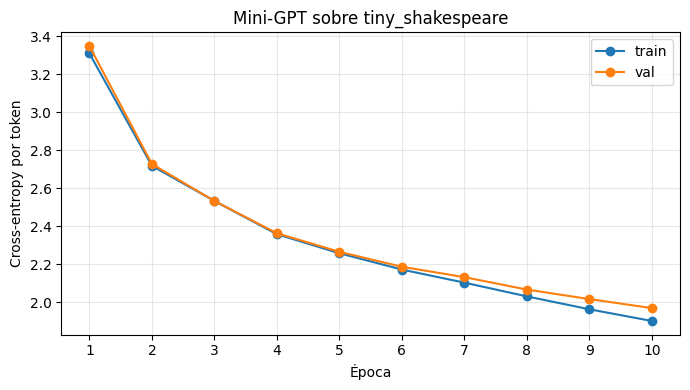

In [13]:
ep = range(1, epochs + 1)
plt.figure(figsize=(7, 4))
plt.plot(ep, history["train"], "o-", label="train")
plt.plot(ep, history["val"], "o-", label="val")
plt.xlabel("Época")
plt.ylabel("Cross-entropy por token")
plt.title("Mini-GPT sobre tiny_shakespeare")
plt.xticks(list(ep))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("loss_task1_2.png", dpi=110)
plt.show()

## Perplejidad de validación

In [14]:
val_loss, N = evaluate(model, val_data)
perplexity = math.exp(val_loss)
print(f"N tokens evaluados: {N}")
print(f"Loss media de validación: {val_loss:.4f}")
print(f"Perplejidad de validación: {perplexity:.4f}")
assert 3.5 <= perplexity <= 8.0, perplexity

N tokens evaluados: 111488
Loss media de validación: 1.9682
Perplejidad de validación: 7.1580


## Muestra generada

In [15]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0):
    model.eval()
    for _ in range(max_new_tokens):
        logits, _ = model(idx[:, -block_size:])
        probs = F.softmax(logits[:, -1, :] / temperature, dim=-1)
        idx = torch.cat([idx, torch.multinomial(probs, num_samples=1)], dim=1)
    model.train()
    return idx

torch.manual_seed(SEED)
context = torch.tensor([encode("\n")], dtype=torch.long, device=device)
print(decode(generate(model, context, 300)[0].tolist()))


Thatsnered: to cof than in sugdignat in the thim.
With lear goom semailable dowely thim,
Ing is Det this cascles miet his fuke gor hough ciceWeShs mimery;
Bun a cour oltl!
LAR SED:
fond es nigklinct.
Shy, his him inturvicor, o' for werer ake,
Ed voblen acter kime thy. 'That Clib's to yiz is that?

D
